In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d stealthknight/bird-vs-drone

Dataset URL: https://www.kaggle.com/datasets/stealthknight/bird-vs-drone
License(s): MIT
100% 1.05G/1.05G [00:10<00:00, 151MB/s]
100% 1.05G/1.05G [00:10<00:00, 104MB/s]


In [3]:
!unzip bird-vs-drone.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/train/labels/DTR (8630).txt  
  inflating: Dataset/train/labels/DTR (8631).txt  
  inflating: Dataset/train/labels/DTR (8632).txt  
  inflating: Dataset/train/labels/DTR (8633).txt  
  inflating: Dataset/train/labels/DTR (8634).txt  
  inflating: Dataset/train/labels/DTR (8635).txt  
  inflating: Dataset/train/labels/DTR (8636).txt  
  inflating: Dataset/train/labels/DTR (8637).txt  
  inflating: Dataset/train/labels/DTR (8638).txt  
  inflating: Dataset/train/labels/DTR (8639).txt  
  inflating: Dataset/train/labels/DTR (864).txt  
  inflating: Dataset/train/labels/DTR (8640).txt  
  inflating: Dataset/train/labels/DTR (8641).txt  
  inflating: Dataset/train/labels/DTR (8642).txt  
  inflating: Dataset/train/labels/DTR (8643).txt  
  inflating: Dataset/train/labels/DTR (8644).txt  
  inflating: Dataset/train/labels/DTR (8645).txt  
  inflating: Dataset/train/labels/DTR (8646).txt  
  inflating: Dataset/train/label

In [4]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

In [5]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False

In [9]:
# generator
train_ds = keras.utils.image_dataset_from_directory(
    '/content/Dataset/train',
    image_size = (150, 150),
    batch_size = 32,
    label_mode = 'int',
    labels = 'inferred'
)

val_ds = keras.utils.image_dataset_from_directory(
    '/content/Dataset/test',
    image_size = (150, 150),
    batch_size = 32,
    label_mode = 'int',
    labels = 'inferred'
)

Found 18323 files belonging to 2 classes.
Found 889 files belonging to 2 classes.


In [10]:
def process(image, label):
  image = tensorflow.cast(image/255.0, tensorflow.float32)
  return image, label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 80s 122ms/step - accuracy: 0.9955 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 65s 113ms/step - accuracy: 1.0000 - loss: 6.2406e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 61s 105ms/step - accuracy: 1.0000 - loss: 6.3337e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 63s 109ms/step - accuracy: 1.0000 - loss: 6.2845e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - accuracy: 1.0000 - loss: 6.4431e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 62s 109ms/step - accuracy: 1.0000 - loss: 6.2593e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 63s 110ms/step - accuracy: 1.0000 - loss: 6.1693e-21 - val_accuracy: 1.0000 - val_loss: 3.0551e-21
Epoch 8/10
573/573 ━━━━━━━━━━━━

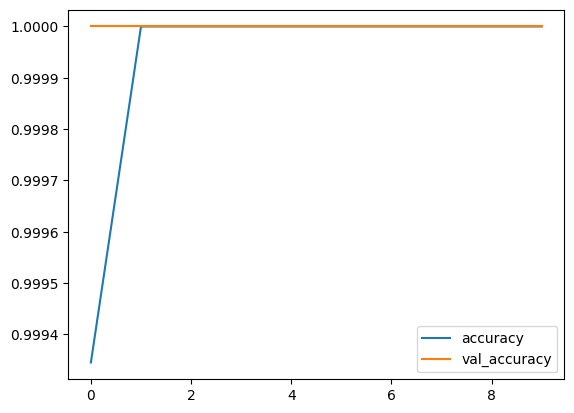

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.legend()
plt.show()


### Data Augmentation

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [21]:
train_generator = train_datagen.flow_from_directory(
    '/content/Dataset/train',
    target_size = (150,150),
    batch_size = batch_size,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/Dataset/test',
    target_size = (150,150),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 18323 images belonging to 2 classes.
Found 889 images belonging to 2 classes.


In [22]:
def process(image, label):
  image = tensorflow.cast(image/255.0, tensorflow.float32)
  return image, label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [23]:
model1 = Sequential()

model1.add(conv_base)
model1.add(Flatten())
model1.add(Dense(256, activation = 'relu'))
model1.add(Dense(1, activation = 'sigmoid'))

In [24]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
history1 = model1.fit(train_ds, epochs=3, validation_data=val_ds)

Epoch 1/3
573/573 ━━━━━━━━━━━━━━━━━━━━ 65s 109ms/step - accuracy: 0.9879 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 1.2478e-13
Epoch 2/3
573/573 ━━━━━━━━━━━━━━━━━━━━ 78s 104ms/step - accuracy: 1.0000 - loss: 1.2547e-13 - val_accuracy: 1.0000 - val_loss: 1.2478e-13
Epoch 3/3
573/573 ━━━━━━━━━━━━━━━━━━━━ 61s 107ms/step - accuracy: 1.0000 - loss: 1.2547e-13 - val_accuracy: 1.0000 - val_loss: 1.2478e-13


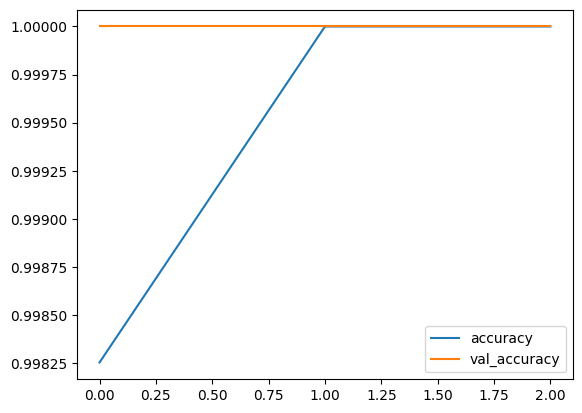

In [27]:
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label = 'val_accuracy')
plt.legend()
plt.show()